# Предсказание предпочтения смартфона методом k ближайших соседей

Цель работы - оценка связи ответов анкеты с предпочитаемой платформой смартфона

In [1]:
# Подключаем библиотеки для загрузки, подготовки данных, обучения и оценки модели
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from practice_1.preprocessing import make_preprocessor

## Данные и признаки

Целевая переменная задаётся по имени. Временная отметка исключена: она описывает порядок заполнения, а не характеристику респондента. Числовым считается только столбец, все непустые значения которого безопасно преобразуются в числа. Вопрос 4 обрабатывается как multi-hot признак: каждый выбранный вариант получает отдельную бинарную колонку. Остальные текстовые ответы остаются категориальными.

In [7]:
# Ищем исходный набор данных при запуске из корня проекта или из practice_1
data_candidates = [
    Path("practice_1/data_utf8.xlsx"),
    Path("data_utf8.xlsx"),
    Path("/practice_1/data_utf8.xlsx"),
]
data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Не найден файл practice_1/data_utf8.xlsx")
data = pd.read_excel(data_path)
# Показываем размер набора и число ответов каждого класса
target_column = "22. У Вас айфон или андроид?"
if target_column not in data.columns:
    raise ValueError(f"В данных отсутствует целевая колонка: {target_column}")

print(f"Размер выборки: {data.shape[0]} наблюдений, {data.shape[1]} столбца")
print("\nБаланс классов:")
display(data[target_column].value_counts().rename_axis(target_column).to_frame("Число наблюдений"))

# Отделяем ответы для прогноза и убираем временную отметку
X = data.drop(columns=[target_column, "Отметка времени"]).copy()
y = data[target_column]
# Определяем числа, а остальные ответы оставляем текстовыми категориями
numeric_features = []
for column in X.columns:
    converted = pd.to_numeric(X[column], errors="coerce")
    if converted.notna().sum() == X[column].notna().sum():
        X[column] = converted
        numeric_features.append(column)
multi_select_column = "4. За что вы готовы переплатить, покупая смартфон?"
if multi_select_column not in X.columns:
    raise ValueError(f"В данных отсутствует multi-select колонка: {multi_select_column}")
categorical_features = X.columns.difference(
    numeric_features + [multi_select_column]
).tolist()

Размер выборки: 41 наблюдений, 23 столбца

Баланс классов:


,Число наблюдений
22. У Вас айфон или андроид?,
Андроид,22
Айфон,19


## Подбор модели

Данные делятся на обучающую и тестовую части стратифицированно в пропорции 80/20. Масштабирование и кодирование выполняются внутри конвейера, поэтому параметры преобразований оцениваются только на обучающих фолдах. Значение `k` выбирается по средней сбалансированной точности в пятикратной стратифицированной кросс-валидации; при равенстве выбирается меньшее `k`.

In [8]:
# Делим данные на части для обучения и итоговой проверки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Готовим числовые, множественные и обычные категориальные ответы
preprocessor = make_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    multi_select_feature=multi_select_column,
)
# Собираем подготовку данных и модель в одну последовательность
pipeline = Pipeline(
    [("preprocessor", preprocessor), ("model", KNeighborsClassifier())]
)
# Пять раз делим обучающие ответы на части: четыре части учат модель, а пятая проверяет её
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Задаём варианты числа ближайших соседей для проверки
search = GridSearchCV(
    pipeline,
    param_grid={"model__n_neighbors": [1, 3, 5, 7]},
    scoring="balanced_accuracy",
    cv=cv,
    refit=False,
)
# Обучаем перебор и сравниваем варианты
search.fit(X_train, y_train)

# Собираем таблицу оценок для каждого значения k
cv_table = (
    pd.DataFrame(search.cv_results_)[["param_model__n_neighbors", "mean_test_score", "std_test_score"]]
    .rename(columns={"param_model__n_neighbors": "k", "mean_test_score": "balanced_accuracy_mean", "std_test_score": "balanced_accuracy_std"})
    .astype({"k": int})
    .sort_values("k")
    .reset_index(drop=True)
)
# Выбираем число соседей, которое лучше различает оба класса; при равенстве берём меньшее число
best_k = int(
    cv_table.sort_values(["balanced_accuracy_mean", "k"], ascending=[False, True]).iloc[0]["k"]
)

display(cv_table)
print(f"Выбранное k: {best_k}")

,k,balanced_accuracy_mean,balanced_accuracy_std
0,1,0.750000,0.126381
1,3,0.591667,0.171594
2,5,0.658333,0.100000
3,7,0.633333,0.187083


Выбранное k: 1


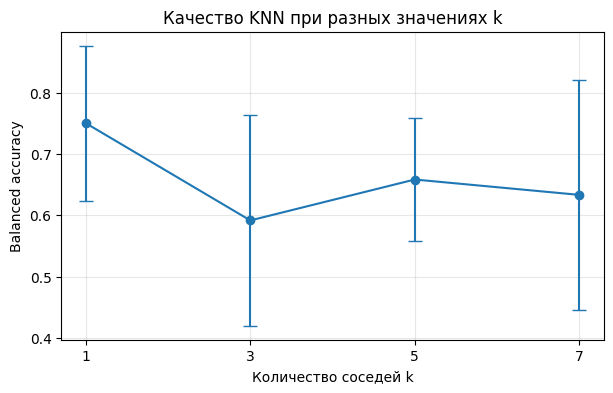

In [9]:
plt.figure(figsize=(7, 4))

plt.errorbar(
    cv_table["k"],
    cv_table["balanced_accuracy_mean"],
    yerr=cv_table["balanced_accuracy_std"],
    marker="o",
    capsize=5,
)

plt.xlabel("Количество соседей k")
plt.ylabel("Balanced accuracy")
plt.title("Качество KNN при разных значениях k")
plt.xticks(cv_table["k"])
plt.grid(alpha=0.3)

plt.show()

## Проверка на тестовой выборке

Итоговая модель обучается только на обучающей части с выбранным значением `k`. Отложенная выборка не участвовала в подборе гиперпараметра.

,Значение
accuracy,0.777778
balanced_accuracy,0.775000
macro_f1,0.775000


Классификационный отчёт:

              precision    recall  f1-score   support

       Айфон       0.75      0.75      0.75         4
     Андроид       0.80      0.80      0.80         5

    accuracy                           0.78         9
   macro avg       0.78      0.78      0.78         9
weighted avg       0.78      0.78      0.78         9



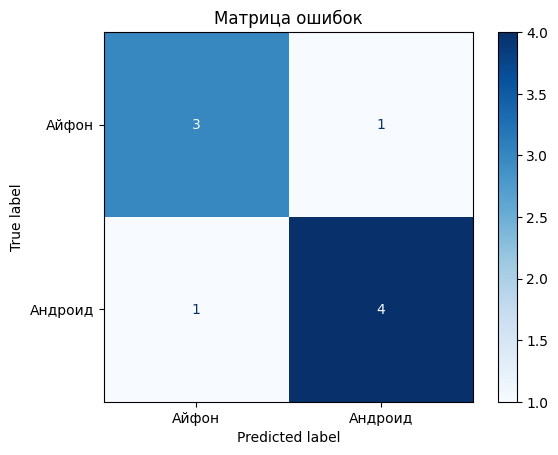

In [10]:
# Обучаем итоговую модель с выбранным числом соседей
model = pipeline.set_params(model__n_neighbors=best_k).fit(X_train, y_train)
# Получаем прогнозы для отложенной части данных
y_pred = model.predict(X_test)

# Считаем метрики и показываем ошибки на отложенной части
metrics = pd.Series(
    {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
    }
)
display(metrics.to_frame("Значение"))
print("Классификационный отчёт:\n")
print(classification_report(y_test, y_pred, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Матрица ошибок")
plt.show()

In [11]:
prediction_table = pd.DataFrame({
    "Факт": y_test,
    "Прогноз": y_pred,
})

prediction_table["Верно"] = (
    prediction_table["Факт"] == prediction_table["Прогноз"]
)

display(prediction_table)

,Факт,Прогноз,Верно
31,Айфон,Айфон,True
13,Айфон,Айфон,True
0,Андроид,Андроид,True
33,Андроид,Айфон,False
22,Андроид,Андроид,True
36,Андроид,Андроид,True
10,Айфон,Андроид,False
4,Андроид,Андроид,True
21,Айфон,Айфон,True


## Вывод и источники

Выбрано значение `k`, дающее наибольшую среднюю сбалансированную точность; при одинаковой оценке предпочтение получает меньшее `k`. При `n=41` оценка имеет высокую неопределённость и чувствительна к конкретному разбиению

## Какая информация взята из статей

### Wu et al. (2021), [«Predicting Chemical Hazard across Taxa through Machine Learning»](https://arxiv.org/abs/2110.03688)

Авторы добавили к главным химическим свойствам контекст — сведения о виде рыб и условиях эксперимента. Они обрабатывали числовые, бинарные и категориальные блоки признаков раздельно: применяли евклидово расстояние к числовым признакам, расстояние Хэмминга к бинарным и категориальным признакам, нормировали расстояния и подбирали веса блоков по кросс-валидации. При объединении информации в их задаче 3-NN достиг accuracy 0.918 и F1 0.890, а модель только с химическими признаками — accuracy 0.841 и F1 0.530

**Перевод фрагмента статьи:**

> «Поскольку наши данные явно разделены на три источника информации, мы можем настроить модели так, чтобы добиться более высокой эффективности»
>
> «Разделение признаков на более мелкие группы может дополнительно повысить эффективность, но потребует более длительного подбора гиперпараметров»

**Что применено в этой работе.** Применён НЕ их специализированный расчёт расстояния, а тот же принцип: числовые ответы масштабируются `RobustScaler`, обычные категориальные ответы кодируются `OneHotEncoder`, а множественные ответы вопроса 4 разбираются `MultiHotEncoder` на отдельные 0/1-признаки. Используются все содержательные вопросы анкеты; временная отметка исключается, поскольку фиксирует время заполнения
